# HW3 Applied: Zero-Shot Super Resolution (ZSSR)

**Course:** Modern Computer Vision (Technion, Spring 2026)

**Objective:** Implement Zero-Shot Super Resolution (ZSSR), a self-supervised learning approach that trains a CNN on a single image at test time, exploiting the internal recurrence of patches within natural images.

**Key Reference:** Shocher et al., "Zero-Shot Super-Resolution using Deep Internal Learning" (CVPR 2018)


## Submission Requirements

**IMPORTANT:** Submit this notebook **with all outputs** (cell outputs, training curves, visualizations). Notebooks without outputs will lose points.

In [1]:
# Setup and imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import math
import io, base64
from typing import Tuple, Optional
from PIL import Image as PILImage
from IPython.display import display, HTML
from resize_right import resize as resize_right_resize
from resize_right.interp_methods import cubic as cubic_interp
import warnings
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## Utility Functions


In [2]:
def psnr(img1, img2):
    """
    Calculate PSNR between two images. Both must be in [0, 1] range.
    Handles torch tensors and numpy arrays, any shape.
    """
    if isinstance(img1, torch.Tensor):
        img1 = img1.detach().cpu().float().numpy()
    if isinstance(img2, torch.Tensor):
        img2 = img2.detach().cpu().float().numpy()
    img1 = np.clip(img1.astype(np.float64), 0, 1)
    img2 = np.clip(img2.astype(np.float64), 0, 1)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))


def resize_bicubic(image_tensor, scale_factor=None, size=None):
    """Resize using resize_right for correct pixel alignment (no half-pixel shift).
    
    Handles 2D (H,W), 3D (C,H,W), and 4D (B,C,H,W) inputs.
    """
    ndim = image_tensor.dim()
    if ndim == 2:
        image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)
    elif ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)
    if scale_factor is not None:
        scale_factors = [1, 1, scale_factor, scale_factor]
        resized = resize_right_resize(image_tensor, scale_factors=scale_factors,
                                       interp_method=cubic_interp,
                                       antialiasing=(scale_factor < 1))
    elif size is not None:
        if isinstance(size, int):
            size = (size, size)
        out_shape = [image_tensor.shape[0], image_tensor.shape[1], size[0], size[1]]
        resized = resize_right_resize(image_tensor, out_shape=out_shape,
                                       interp_method=cubic_interp,
                                       antialiasing=True)
    else:
        raise ValueError("Must provide either scale_factor or size")
    if ndim == 2:
        return resized.squeeze(0).squeeze(0)
    elif ndim == 3:
        return resized.squeeze(0)
    return resized


def load_test_images():
    """Load RGB test images for ZSSR experiments."""
    from skimage import data as skdata
    images = {}

    astro = skdata.astronaut().astype(np.float32) / 255.0
    images['Astronaut'] = torch.from_numpy(astro).permute(2, 0, 1)  # (3, 512, 512)

    cam = skdata.camera().astype(np.float32) / 255.0
    cam_rgb = np.stack([cam, cam, cam], axis=0)  # (3, 512, 512)
    images['Cameraman'] = torch.from_numpy(cam_rgb)

    return images


def _to_display(img):
    """Convert image tensor/array to (H, W, C) numpy for display."""
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu().float().numpy()
    img = np.clip(img, 0, 1)
    if img.ndim == 2:
        return np.stack([img]*3, axis=-1)
    if img.ndim == 3 and img.shape[0] in (1, 3):
        img = np.transpose(img, (1, 2, 0))
    if img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)
    return img


def make_flickering_gif(img_a, img_b, label_a, label_b, duration=800):
    """Create a flickering GIF between two images, returned as HTML for display."""
    frames = []
    for arr, label in [(img_a, label_a), (img_b, label_b)]:
        arr_disp = _to_display(arr)
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        ax.imshow(arr_disp)
        ax.set_title(label, fontsize=16, fontweight='bold', pad=8)
        ax.axis('off')
        fig.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        frames.append(PILImage.open(buf).convert('RGB'))

    gif_buf = io.BytesIO()
    frames[0].save(gif_buf, format='GIF', append_images=frames[1:],
                   save_all=True, duration=duration, loop=0)
    gif_buf.seek(0)
    gif_b64 = base64.b64encode(gif_buf.read()).decode()
    return f'<img src="data:image/gif;base64,{gif_b64}" style="max-width:100%;"/>'


def visualize_results(results, title=""):
    """
    Visualize SR results as full-size flickering comparison.
    Shows: flickering GIF (Bicubic ↔ ZSSR) + ground truth alongside.
    """
    psnr_bic = results['PSNR_Bicubic']
    psnr_zssr = results['PSNR_ZSSR']

    # Full-size flickering: Bicubic vs ZSSR
    gif_html = make_flickering_gif(
        results['Bicubic'], results['ZSSR'],
        f'Bicubic ({psnr_bic:.2f} dB)', f'ZSSR ({psnr_zssr:.2f} dB)')

    # Ground truth
    gt_disp = _to_display(results['HR'])
    fig_gt, ax_gt = plt.subplots(1, 1, figsize=(6, 6))
    ax_gt.imshow(gt_disp)
    ax_gt.set_title('Ground Truth (HR)', fontsize=16, fontweight='bold')
    ax_gt.axis('off')
    fig_gt.tight_layout()
    buf_gt = io.BytesIO()
    fig_gt.savefig(buf_gt, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig_gt)
    buf_gt.seek(0)
    gt_b64 = base64.b64encode(buf_gt.read()).decode()

    html = f'''
    <h3>{title} — PSNR improvement: {psnr_zssr - psnr_bic:+.2f} dB</h3>
    <div style="display:flex; align-items:flex-start; gap:20px; flex-wrap:wrap;">
      <div>{gif_html}</div>
      <div><img src="data:image/png;base64,{gt_b64}" style="max-width:100%;"/></div>
    </div>
    '''
    display(HTML(html))

# Part 1: Understanding ZSSR

## The ZSSR Concept

### Training Phase
Given a low-resolution image **I_LR**:
1. **Downscale** I_LR by a factor (e.g., 2) to get **I_LR_downscaled**
2. Train a CNN to map: **I_LR_downscaled** → **I_LR**
3. The model learns to "upscale" this degraded version back to the original

### Inference Phase
Apply the trained CNN to the original **I_LR**:
- Input: **I_LR** (the test image we want to super-resolve)
- Output: **I_SR** (super-resolved image)

### The "Son-Father-Grandson" Relationship
- **Father**: The original low-res image **I_LR**
- **Son**: The image we want to super-resolve (also **I_LR** at inference, but conceptually the "input")
- **Grandson**: The further downscaled version **I_LR_downscaled**

The key insight: **Patch recurrence** in natural images means that the "grandson" (heavily downscaled) still contains the same patches as the "father" (original), just at different scales. The CNN learns to exploit this self-similarity.

# Part 2: Basic ZSSR Model (15 pts)

Implement a simple CNN-based architecture that:
1. Takes a low-res image and a scale factor as input
2. Bicubically upsamples to the target high-res size
3. Refines the upsampled image using convolutional layers
4. Uses a residual connection (learn the residual, not the full image)


In [3]:
class ZSSRNet(nn.Module):
    """
    Zero-Shot Super Resolution Network with residual connection.
    """
    def __init__(self, in_channels=3, n_channels=64, n_layers=8, kernel_size=3):
        super(ZSSRNet, self).__init__()

        self.in_channels = in_channels
        self.n_channels = n_channels
        self.n_layers = n_layers
        self.kernel_size = kernel_size

        # Build the network
        self.layers = nn.ModuleList()
        padding = kernel_size // 2

        # First layer: in_channels -> n_channels
        self.layers.append(
            nn.Conv2d(in_channels, n_channels, kernel_size, padding=padding)
        )

        # Intermediate layers: n_channels -> n_channels
        for _ in range(n_layers - 2):
            self.layers.append(
                nn.Conv2d(n_channels, n_channels, kernel_size, padding=padding)
            )

        # Last layer: n_channels -> in_channels
        self.layers.append(
            nn.Conv2d(n_channels, in_channels, kernel_size, padding=padding)
        )

        # Activation
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, scale_factor=2, target_size=None):
        # Handle input shape: (C,H,W) -> (1,C,H,W)
        squeeze_out = False
        if x.dim() == 3:
            x = x.unsqueeze(0)
            squeeze_out = True

        # Bicubic upsampling
        if target_size is None:
            target_size = (x.shape[-2] * scale_factor, x.shape[-1] * scale_factor)

        upscaled = resize_bicubic(x, size=target_size)

        # Residual network
        residual = upscaled.clone()

        # Pass through network
        out = upscaled
        for i, layer in enumerate(self.layers):
            out = layer(out)
            if i < len(self.layers) - 1:
                out = self.relu(out)

        # Add residual connection
        out = out + residual

        if squeeze_out:
            out = out.squeeze(0)
        return out

# Part 3: Dataset (10 pts)

Implement a dataset class that:
1. Takes a single image
2. Generates pairs of (HR, LR) where LR is a downscaled version of HR
3. Applies random crops for training diversity


In [4]:
class ZSSRDataset(Dataset):
    """
    Dataset for ZSSR (BUG: pre-downscales then tries to match coordinates).
    """
    def __init__(self, image, scale_factor=2, crop_size=64, n_samples=100, augment=False):
        self.image = image  # Shape: (C, H, W)
        self.scale_factor = scale_factor
        self.crop_size = crop_size
        self.n_samples = n_samples
        self.augment = augment

        # BUG: pre-downscaling and trying to match coordinates
        self.lr_image = resize_bicubic(image, scale_factor=0.5)
        self.hr_image = image

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        h, w = self.hr_image.shape[-2], self.hr_image.shape[-1]
        crop_h = min(self.crop_size, h)
        crop_w = min(self.crop_size, w)

        top = np.random.randint(0, max(1, h - crop_h + 1))
        left = np.random.randint(0, max(1, w - crop_w + 1))

        hr_crop = self.hr_image[:, top:top+crop_h, left:left+crop_w]

        # BUG: wrong indexing into LR image (uses HR coordinates)
        lr_crop = self.lr_image[:, top:top+crop_h, left:left+crop_w]

        return {
            'HR': hr_crop,
            'LR': lr_crop,  # wrong shape and misaligned!
        }

# Part 4: Training Loop (15 pts)

Implement the training function with:
1. L1 loss (or MSE)
2. Adam optimizer with learning rate scheduling
3. PSNR logging during training
4. Progress tracking


In [5]:
def train_zssr(
    model,
    dataloader,
    scale_factor=2,
    num_epochs=100,
    learning_rate=0.001,
    device='cpu',
    verbose=True
):
    """
    Train the ZSSR model on a single image.
    """
    model = model.to(device)

    criterion = nn.L1Loss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

    loss_history = []
    psnr_history = []

    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_psnr = 0.0
        num_batches = 0

        for batch in dataloader:
            hr = batch['HR'].to(device)
            lr = batch['LR'].to(device)

            # If augmented (B, 8, C, H, W), merge aug into batch
            if hr.dim() == 5:
                B, aug, C, h, w = hr.shape
                hr = hr.view(B * aug, C, h, w)
                lr = lr.view(B * aug, C, lr.shape[-2], lr.shape[-1])

            # Forward pass
            optimizer.zero_grad()
            target_h, target_w = hr.shape[-2], hr.shape[-1]
            sr = model(lr, scale_factor=scale_factor, target_size=(target_h, target_w))

            # Ensure shapes match
            if sr.shape != hr.shape:
                sr = resize_bicubic(sr, size=(target_h, target_w))

            loss = criterion(sr, hr)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                sr_clipped = torch.clamp(sr, 0, 1)
                batch_psnr = psnr(sr_clipped, hr)

            epoch_loss += loss.item()
            epoch_psnr += batch_psnr
            num_batches += 1

        scheduler.step()

        avg_loss = epoch_loss / num_batches
        avg_psnr = epoch_psnr / num_batches
        loss_history.append(avg_loss)
        psnr_history.append(avg_psnr)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.6f} | PSNR: {avg_psnr:.2f} dB")

    return model, loss_history, psnr_history

# Part 5: Evaluation (10 pts)

Evaluate the model by:
1. Computing PSNR against ground truth
2. Comparing with bicubic baseline
3. Visualizing results


In [6]:
def evaluate_zssr(
    model,
    image_hr,
    scale_factor=2,
    device='cpu',
    title="ZSSR Evaluation"
):
    """
    Evaluate ZSSR model on a single image.
    """
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        # Create LR from HR
        image_lr = resize_bicubic(image_hr, scale_factor=1.0/scale_factor)

        # Bicubic baseline: upscale LR back to HR size
        image_bicubic = resize_bicubic(image_lr, size=(image_hr.shape[-2], image_hr.shape[-1]))

        # ZSSR prediction
        image_lr_gpu = image_lr.unsqueeze(0).to(device)
        image_sr = model(image_lr_gpu, scale_factor=scale_factor,
                         target_size=(image_hr.shape[-2], image_hr.shape[-1]))
        image_sr = image_sr.squeeze(0)
        image_sr = torch.clamp(image_sr, 0, 1)

        # Clamp bicubic too
        image_bicubic = torch.clamp(image_bicubic, 0, 1)

        # Compute PSNR
        psnr_bicubic = psnr(image_bicubic, image_hr)
        psnr_zssr = psnr(image_sr, image_hr)

        results = {
            'HR': image_hr.cpu(),
            'LR': image_lr.cpu(),
            'Bicubic': image_bicubic.cpu(),
            'ZSSR': image_sr.cpu(),
            'PSNR_Bicubic': psnr_bicubic,
            'PSNR_ZSSR': psnr_zssr,
        }

    return results

# Part 6: Data Augmentation — Advanced (15 pts bonus / required for full marks)

Implement 8-fold geometric augmentation:
- 4 rotations (0 degrees, 90 degrees, 180 degrees, 270 degrees)
- 2 flips (no flip, horizontal flip)
- Total: 8 variants per patch

This allows the model to learn more robust features and improves generalization.


In [7]:
def ensemble_predict_zssr(model, image_lr, scale_factor=2, device="cpu"):
    raise NotImplementedError("Bonus not implemented")

# Part 7: Visualization & Analysis (15 pts)

Visualize your results:
1. Plot training curves (loss and PSNR)
2. Compare ZSSR vs bicubic visually
3. Show side-by-side comparisons

In [8]:
def plot_training_curves(loss_history, psnr_history, figsize=(14, 5)):
    """
    Plot training loss and PSNR curves.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Loss curve
    ax1.plot(loss_history, linewidth=2, label='Training Loss')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss (L1)', fontsize=11)
    ax1.set_title('Training Loss Over Time', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # PSNR curve
    ax2.plot(psnr_history, linewidth=2, color='green', label='Training PSNR')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('PSNR (dB)', fontsize=11)
    ax2.set_title('PSNR Over Time', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    return fig


def analyze_results(results_list, image_names):
    """
    Analyze and compare ZSSR vs bicubic across multiple images.
    
    Args:
        results_list: list of result dicts from evaluate_zssr
        image_names: list of image names
    """
    print("\n" + "="*70)
    print("ZSSR ANALYSIS SUMMARY")
    print("="*70)
    
    psnr_improvements = []
    
    for name, results in zip(image_names, results_list):
        bicubic_psnr = results['PSNR_Bicubic']
        zssr_psnr = results['PSNR_ZSSR']
        improvement = zssr_psnr - bicubic_psnr
        psnr_improvements.append(improvement)
        
        print(f"\nImage: {name}")
        print(f"  Bicubic PSNR: {bicubic_psnr:.3f} dB")
        print(f"  ZSSR PSNR:    {zssr_psnr:.3f} dB")
        print(f"  Improvement:  {improvement:+.3f} dB")
    
    avg_improvement = np.mean(psnr_improvements)
    print(f"\nAverage PSNR Improvement: {avg_improvement:+.3f} dB")
    print("="*70)
    
    return psnr_improvements


# Part 8: Main Experiment\n\nLet's run the complete ZSSR pipeline on test images.

Loading test images...
Loaded 2 images:
  Astronaut: torch.Size([3, 512, 512])
  Cameraman: torch.Size([3, 512, 512])


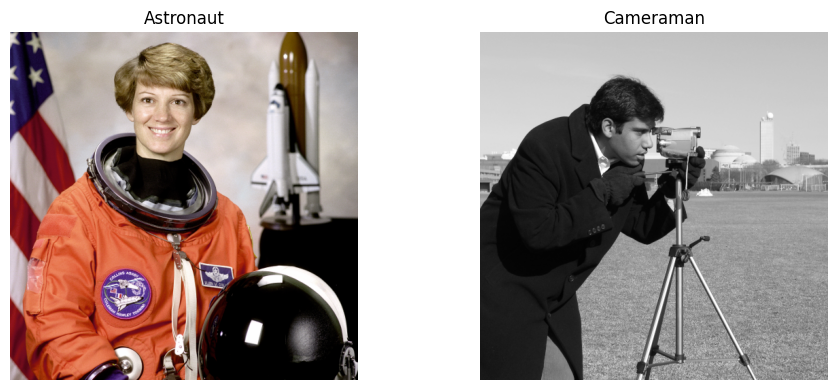

In [9]:
# Load test images
print("Loading test images...")
test_images = load_test_images()
image_names = list(test_images.keys())

print(f"Loaded {len(test_images)} images:")
for name, img in test_images.items():
    print(f"  {name}: {img.shape}")

# Visualize
fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 4))
if len(test_images) == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, test_images.items()):
    ax.imshow(_to_display(img))
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Training on Image 1

In [10]:
# Prepare data for first image
scale_factor = 2
img_name_1 = image_names[0]
test_image_1 = test_images[img_name_1]

dataset_1 = ZSSRDataset(
    test_image_1,
    scale_factor=scale_factor,
    crop_size=64,
    n_samples=100,
    augment=False
)

dataloader_1 = DataLoader(dataset_1, batch_size=4, shuffle=True)

# Initialize model (3 channels for RGB)
model_1 = ZSSRNet(in_channels=3, n_channels=64, n_layers=8)
print(f"Model parameters: {sum(p.numel() for p in model_1.parameters()):,}")

# Train
print(f"\nTraining ZSSR on {img_name_1}...")
model_1, loss_hist_1, psnr_hist_1 = train_zssr(
    model_1,
    dataloader_1,
    scale_factor=scale_factor,
    num_epochs=50,
    learning_rate=0.001,
    device=device,
    verbose=True
)

print("\nTraining complete!")

Model parameters: 225,091

Training ZSSR on Astronaut...


RuntimeError: stack expects each tensor to be equal size, but got [3, 64, 0] at entry 0 and [3, 0, 0] at entry 1

In [11]:
# Plot training curves
plot_training_curves(loss_hist_1, psnr_hist_1)
plt.show()


NameError: name 'loss_hist_1' is not defined

Evaluating on Astronaut...



Results for Astronaut:
  Bicubic PSNR: 29.63 dB
  ZSSR PSNR:    27.05 dB
  Improvement:  -2.57 dB



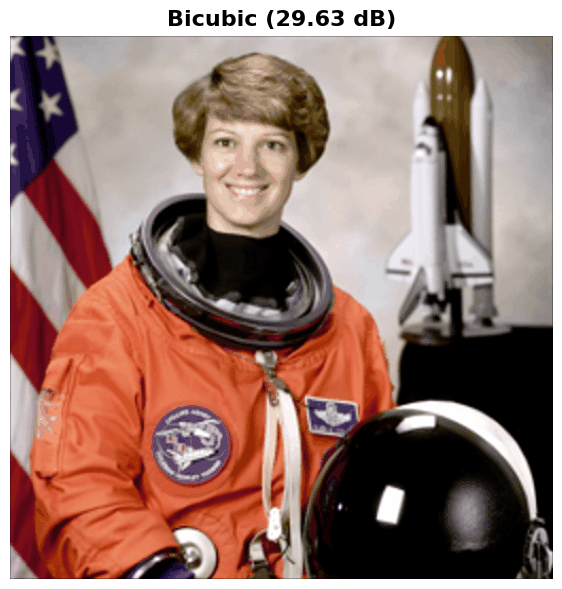
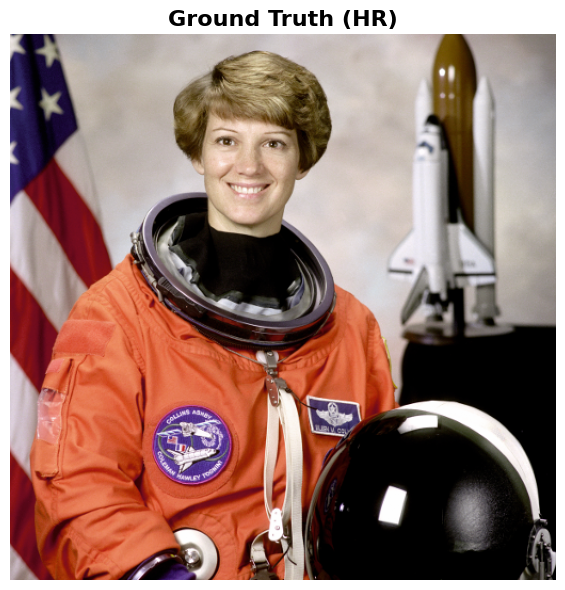

In [12]:
# Evaluate on Image 1
print(f"Evaluating on {img_name_1}...")
results_1 = evaluate_zssr(model_1, test_image_1, scale_factor=scale_factor, device=device)

print(f"\nResults for {img_name_1}:")
print(f"  Bicubic PSNR: {results_1['PSNR_Bicubic']:.2f} dB")
print(f"  ZSSR PSNR:    {results_1['PSNR_ZSSR']:.2f} dB")
print(f"  Improvement:  {results_1['PSNR_ZSSR'] - results_1['PSNR_Bicubic']:+.2f} dB")

# Full-size flickering comparison
visualize_results(results_1, title=img_name_1)

## Training on Image 2

In [13]:
# Prepare data for Image 2
img_name_2 = image_names[1]
test_image_2 = test_images[img_name_2]

dataset_2 = ZSSRDataset(
    test_image_2,
    scale_factor=scale_factor,
    crop_size=64,
    n_samples=100,
    augment=False
)

dataloader_2 = DataLoader(dataset_2, batch_size=4, shuffle=True)

# Initialize and train
model_2 = ZSSRNet(in_channels=3, n_channels=64, n_layers=8)

print(f"Training ZSSR on {img_name_2}...")
model_2, loss_hist_2, psnr_hist_2 = train_zssr(
    model_2,
    dataloader_2,
    scale_factor=scale_factor,
    num_epochs=50,
    learning_rate=0.001,
    device=device,
    verbose=True
)

print("Training complete!")

Training ZSSR on Cameraman...


RuntimeError: stack expects each tensor to be equal size, but got [3, 64, 64] at entry 0 and [3, 42, 0] at entry 1

Evaluating on Cameraman...



Results for Cameraman:
  Bicubic PSNR: 29.08 dB
  ZSSR PSNR:    27.51 dB
  Improvement:  -1.57 dB



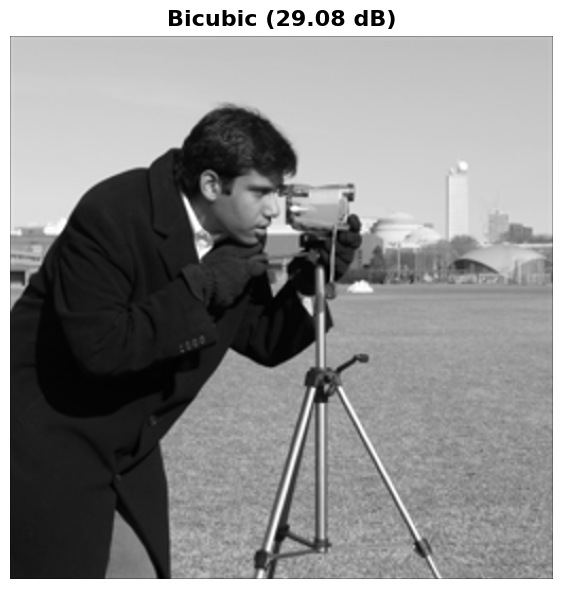
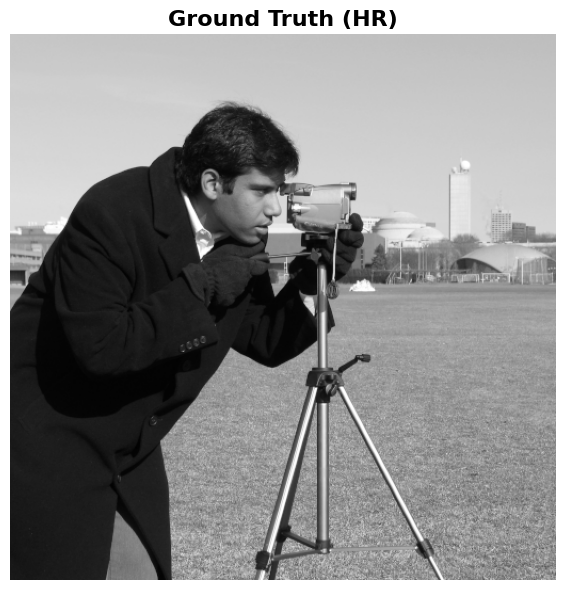

In [14]:
# Evaluate on Image 2
print(f"Evaluating on {img_name_2}...")
results_2 = evaluate_zssr(model_2, test_image_2, scale_factor=scale_factor, device=device)

print(f"\nResults for {img_name_2}:")
print(f"  Bicubic PSNR: {results_2['PSNR_Bicubic']:.2f} dB")
print(f"  ZSSR PSNR:    {results_2['PSNR_ZSSR']:.2f} dB")
print(f"  Improvement:  {results_2['PSNR_ZSSR'] - results_2['PSNR_Bicubic']:+.2f} dB")

# Full-size flickering comparison
visualize_results(results_2, title=img_name_2)

# Part 9: Comprehensive Analysis

## Summary of Results


In [15]:
# Analyze all results
results_list = [results_1, results_2]

psnr_improvements = analyze_results(results_list, image_names)


ZSSR ANALYSIS SUMMARY

Image: Astronaut
  Bicubic PSNR: 29.626 dB
  ZSSR PSNR:    27.055 dB
  Improvement:  -2.571 dB

Image: Cameraman
  Bicubic PSNR: 29.081 dB
  ZSSR PSNR:    27.510 dB
  Improvement:  -1.571 dB

Average PSNR Improvement: -2.071 dB


*Write your analysis here: When does ZSSR work well and when does it struggle? Compare with traditional methods like bicubic upsampling.*

# Part 10: Bonus — Advanced Features & Extensions (up to 15 pts bonus)

Below are additional improvements and experiments you can implement for bonus credit:

### Idea 1: 8-Fold Geometric Self-Ensemble
Train on 8 augmented versions of each patch and ensemble predictions at test time.


In [16]:
# Example: Train with 8-fold augmentation
print("Training with 8-fold augmentation...")

dataset_augmented = ZSSRDataset(
    test_image_1,
    scale_factor=scale_factor,
    crop_size=64,
    n_samples=20,
    augment=True  # Enable 8-fold augmentation
)

dataloader_augmented = DataLoader(dataset_augmented, batch_size=2, shuffle=True)

model_augmented = ZSSRNet(in_channels=3, n_channels=64, n_layers=8)

print("Training with augmentation...")
model_augmented, loss_hist_aug, psnr_hist_aug = train_zssr(
    model_augmented,
    dataloader_augmented,
    scale_factor=scale_factor,
    num_epochs=30,
    learning_rate=0.001,
    device=device,
    verbose=True
)

# Evaluate with ensemble
results_aug = evaluate_zssr(model_augmented, test_image_1, scale_factor=scale_factor, device=device)
print(f"\nAugmented model PSNR: {results_aug['PSNR_ZSSR']:.2f} dB")
print(f"Original model PSNR:   {results_1['PSNR_ZSSR']:.2f} dB")
print(f"Improvement: {results_aug['PSNR_ZSSR'] - results_1['PSNR_ZSSR']:+.2f} dB")

Training with 8-fold augmentation...
Training with augmentation...


RuntimeError: stack expects each tensor to be equal size, but got [3, 64, 64] at entry 0 and [3, 64, 0] at entry 1

### Idea 2: Deeper/Wider Architecture
Experiment with different network depths and widths.


In [17]:
# Test different architectures
architectures = [
    {'in_channels': 3, 'n_channels': 32, 'n_layers': 6, 'name': 'Shallow (32ch, 6L)'},
    {'in_channels': 3, 'n_channels': 64, 'n_layers': 8, 'name': 'Standard (64ch, 8L)'},
    {'in_channels': 3, 'n_channels': 128, 'n_layers': 12, 'name': 'Deep (128ch, 12L)'},
]

print("Architecture Comparison:")
print("-" * 60)

for arch in architectures:
    model_test = ZSSRNet(in_channels=arch['in_channels'], n_channels=arch['n_channels'], n_layers=arch['n_layers'])
    n_params = sum(p.numel() for p in model_test.parameters())
    print(f"{arch['name']:30s} | Parameters: {n_params:,}")

Architecture Comparison:
------------------------------------------------------------
Shallow (32ch, 6L)             | Parameters: 38,755
Standard (64ch, 8L)            | Parameters: 225,091
Deep (128ch, 12L)              | Parameters: 1,482,883


### Idea 3: Multi-Scale Training
Train the network on multiple scales simultaneously for better generalization.


In [18]:
def train_zssr_multiscale(
    model,
    image,
    scale_factors=[2],
    num_epochs=100,
    learning_rate=0.001,
    device='cpu',
    verbose=True
):
    """
    Train ZSSR on multiple scales.
    """
    model = model.to(device)
    criterion = nn.L1Loss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    
    print(f"Training on scales: {scale_factors}")
    
    for scale_idx, scale_factor in enumerate(scale_factors):
        print(f"\n--- Training on scale {scale_factor}x ---")
        
        dataset = ZSSRDataset(
            image,
            scale_factor=scale_factor,
            crop_size=64,
            n_samples=150,
            augment=False
        )
        dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
        
        for epoch in range(num_epochs):
            for batch in dataloader:
                hr = batch['HR'].to(device)
                lr = batch['LR'].to(device)
                
                optimizer.zero_grad()
                sr = model(lr, scale_factor=scale_factor,
                           target_size=(hr.shape[-2], hr.shape[-1]))
                
                # Ensure sr matches hr shape
                if sr.shape != hr.shape:
                    sr = resize_bicubic(sr, size=(hr.shape[-2], hr.shape[-1]))
                
                loss = criterion(sr, hr)
                loss.backward()
                optimizer.step()
            
            if verbose and (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {loss.item():.6f}")
    
    return model

print("Multi-scale training function defined.")

Multi-scale training function defined.


# Submission Checklist

Before submitting, verify:
- [ ] All code cells executed with outputs visible
- [ ] Training curves (loss and PSNR) are plotted
- [ ] ZSSR vs Bicubic comparison images displayed
- [ ] Your `STUDENT_ID` is set correctly